In [1]:
import pandas as pd
import numpy as np
import pickle
from ScanImageTiffReader import ScanImageTiffReader
import os
import matplotlib.pyplot as plt
import scipy.signal
from scipy.stats import norm
from tqdm import tqdm
import tifffile
from scipy.signal import butter, lfilter,find_peaks, convolve
from scipy.signal.windows import gaussian
from ibllib.io.video import *
import scipy.ndimage
import cv2
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML
from matplotlib.animation import PillowWriter
from ScanImageTiffReader import ScanImageTiffReader
import json
from murphlib.caimage import *
from murphlib.tools import *
from murphlib.plotting import *
from murphlib.regression import *
from sklearn.decomposition import PCA
from sklearn.metrics import explained_variance_score
from scipy.stats import zscore
import scipy.io
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import fcluster
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import seaborn as sns
import ibllib.io.raw_data_loaders as rawio
from ibllib.io.extractors.training_wheel import get_wheel_position, extract_wheel_moves, extract_wheel_velocity
import brainbox.behavior.wheel as wh
plt.rcParams['animation.ffmpeg_path'] = r'D:\ffmpeg\bin\ffmpeg.exe'
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score

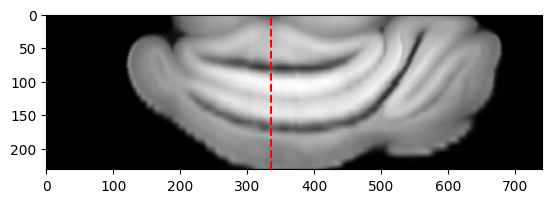

In [2]:
atlas_template = np.load(r'I:\Cerebellum_Imaging_Dec2025\Registration\atlas_template_slice51.npy')
atlas_template = atlas_template[999:1230, 199:940]
plt.imshow(atlas_template, cmap='gray')
plt.axvline(x=335, color='red', linestyle='--')

In [5]:
agg_data = {}
behav_train_path = r'I:\Cerebellum_imaging_Dec2025\training_data'
ca_img_path = r'I:\Cerebellum_Imaging_Dec2025'
# mouse_ids = ['AE_L2', 'AE_L3', 'AF_R3', 'AF_L2', 'AF_L3', 'AB_R2', 'J_L2', 'A_R2', 'A_R3', 'O_R2', 'R_L2'] 
mouse_ids = ['AE_L2', 'AE_L3', 'AF_R3', 'AF_L2', 'AB_R2', 'J_L2', 'A_R2', 'A_R3', 'O_R2', 'R_L2'] 
#mouse_ids = ['AE_L2']
for mouse in mouse_ids:
    mouse_path = os.path.join(ca_img_path, mouse)
    
    subdir = [d for d in os.listdir(mouse_path)]
    dates = [s for s in subdir if (
        s.isdigit() or 
        (s.endswith('_valvesilent') and s[:-12].isdigit()) or
        (s.endswith('_valvesilent_punishsilent') and s[:-25].isdigit())
    )]

    mouse_data = {key: {} for key in dates + ['training']}
    for date in dates:
        session_path = os.path.join(mouse_path, date)
        bhv_path = os.path.join(session_path, 'behavior')
        facemap_folder = os.path.join(bhv_path, 'raw_video_data')
        subdir = [d for d in os.listdir(session_path)]
        if 'arm1' in subdir:
            arm1_img_path = os.path.join(session_path, 'arm1')
            arm1_stat = get_stat_with_coord(arm1_img_path)
            try:
                arm1_ridge_model = np.load(os.path.join(arm1_img_path, 'ridge_model_with_bootstrap_with_roi_motion_no_pupil_wheel.npy'), allow_pickle=True)
            except:
                print(f"Ridge model with motion but no pupil/wheel not found for {mouse} {date} arm1...")
            predictors = arm1_ridge_model[0]['predictors']
            unique_predictors = arm1_ridge_model[0]['unique_predictors']
            arm1_stat = attach_reg_model_to_stat(arm1_stat, arm1_ridge_model) # bonferroni correction applied to bootstrap p-values
            mouse_data[date]['arm1'] = {}
            mouse_data[date]['arm1']['stat'] = np.array(arm1_stat, dtype=object)
            mouse_data[date]['arm1']['table_for_img'] = pd.read_csv(arm1_img_path+'\\table_for_regression.csv')
            mouse_data[date]['arm1']['design_matrix'] = np.load(os.path.join(arm1_img_path, 'design_matrix.npy'))
            
        if 'arm2' in subdir:
            arm2_img_path = os.path.join(session_path, 'arm2')
            arm2_stat = get_stat_with_coord(arm2_img_path)
            try:
                arm2_ridge_model = np.load(os.path.join(arm2_img_path, 'ridge_model_with_bootstrap_with_roi_motion_no_pupil_wheel.npy'), allow_pickle=True)
            except:
                print(f"Ridge model with motion but no pupil/wheel not found for {mouse} {date} arm2...")
            predictors = arm2_ridge_model[0]['predictors']
            unique_predictors = arm2_ridge_model[0]['unique_predictors']
            arm2_stat = attach_reg_model_to_stat(arm2_stat, arm2_ridge_model) # bonferroni correction applied to bootstrap p-values
            mouse_data[date]['arm2'] = {}
            mouse_data[date]['arm2']['stat'] = np.array(arm2_stat, dtype=object)
            mouse_data[date]['arm2']['table_for_img'] = pd.read_csv(arm2_img_path+'\\table_for_regression.csv')
            mouse_data[date]['arm2']['design_matrix'] = np.load(os.path.join(arm2_img_path, 'design_matrix.npy'))
            

        save_dict = np.load(os.path.join(
            r'I:\Cerebellum_imaging_Dec2025',
            mouse,
            date,
            'behavior',
            'raw_video_data',
            "face_ind_roi_motion_decode_ipca.npz"
        ), allow_pickle=True)
        roi_regions = save_dict["regions"].tolist()  # Convert from numpy array to list
        roi_regions.remove('all')
        for region in roi_regions:
            mouse_data[date][f"{region}_motion"] = save_dict[f"{region}_motion"]   # shape (T_video, K)

            
        mouse_data[date]['pupil_area'] = np.load(os.path.join(facemap_folder, 'pupil_area.npy')) # synced to table for video
        mouse_data[date]['pupil_xpos'] = np.load(os.path.join(facemap_folder, 'pupil_xpos.npy'))
        mouse_data[date]['pupil_ypos'] = np.load(os.path.join(facemap_folder, 'pupil_ypos.npy'))
        mouse_data[date]['body_motion'] = np.load(os.path.join(facemap_folder, 'bodymotion_svd.npy'))
        mouse_data[date]['face_motion'] = np.load(os.path.join(facemap_folder, 'facemotion_svd.npy'))
        mouse_data[date]['lick'] = np.load(os.path.join(facemap_folder, 'lickmotion_svd.npy'))
        mouse_data[date]['pupil_area'] = fill_nan_with_previous(mouse_data[date]['pupil_area'])
        mouse_data[date]['pupil_xpos'] = fill_nan_with_previous(mouse_data[date]['pupil_xpos'])
        mouse_data[date]['pupil_ypos'] = fill_nan_with_previous(mouse_data[date]['pupil_ypos'])
        mouse_data[date]['table_for_video'] = pd.read_csv(bhv_path+'\\table_for_video.csv')
        mouse_data[date]['trials_table'] = pd.read_parquet(bhv_path+'\\alf\\_ibl_trials.table.pqt')
        
        bpod_trials = rawio.load_data(bhv_path, task_collection='raw_behavior_data')
        ts, pos = get_wheel_position(bhv_path, bpod_trials, task_collection='raw_behavior_data')
        interp_pos, interp_ts = wh.interpolate_position(ts, pos, freq=1000)
        wheel_moves = extract_wheel_moves(ts, pos, display=False)
        mouse_data[date]['wheel_vel'] = extract_wheel_velocity(interp_pos) # synced to trials table
        mouse_data[date]['wheel_ts'] = interp_ts
        mouse_data[date]['wheel_pos'] = interp_pos
    
    os.makedirs(os.path.join(mouse_path, 'figures'), exist_ok=True)
    mouse_data['training']['accuracies_vis'] = np.load(os.path.join(behav_train_path,mouse, 'accuracies_vis.npy')) 
    mouse_data['training']['accuracies_aud'] = np.load(os.path.join(behav_train_path,mouse, 'accuracies_aud.npy'))
    mouse_data['training']['num_trials'] = np.load(os.path.join(behav_train_path,mouse, 'num_trials.npy'))  
    mouse_data['training']['training_dates'] = np.load(os.path.join(behav_train_path,mouse, 'training_dates.npy'))
    
    agg_data[mouse] = mouse_data
    

2026-02-25 11:06:19.187 WARNING  [raw_data_loaders.py:655] _iblrig_encoderPositions.raw.ssv rotary encoder timestamps swapped at index: 117657  I:\Cerebellum_Imaging_Dec2025\AE_L2\20250729_valvesilent\behavior\raw_behavior_data\_iblrig_encoderPositions.raw.ssv
2026-02-25 11:07:28.960 WARNING  [raw_data_loaders.py:655] _iblrig_encoderPositions.raw.ssv rotary encoder timestamps swapped at index: 113967  I:\Cerebellum_Imaging_Dec2025\AE_L3\20250617_valvesilent\behavior\raw_behavior_data\_iblrig_encoderPositions.raw.ssv
2026-02-25 11:08:58.684 WARNING  [raw_data_loaders.py:655] _iblrig_encoderPositions.raw.ssv rotary encoder timestamps swapped at index: 66038  I:\Cerebellum_Imaging_Dec2025\AE_L3\20250722_valvesilent\behavior\raw_behavior_data\_iblrig_encoderPositions.raw.ssv
2026-02-25 11:08:58.687 WARNING  [raw_data_loaders.py:655] _iblrig_encoderPositions.raw.ssv rotary encoder timestamps swapped at index: 177585  I:\Cerebellum_Imaging_Dec2025\AE_L3\20250722_valvesilent\behavior\raw_beha

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# -------------------------------
# Utility helpers
# -------------------------------

def rolling_average(x, w=3):
    x = np.asarray(x, dtype=float)
    if w <= 1 or x.size == 0:
        return x
    pad = np.pad(x, (w-1, 0), mode='edge')
    c = np.cumsum(pad)
    out = (c[w:] - c[:-w]) / w
    head = np.full(w-1, out[0])
    return np.concatenate([head, out])

def classify_day_stage(vis_perf, aud_perf, vis_raw, aud_raw, perf_thresh=0.65):
    """
    Returns: 'naive' | 'vis_expert' | 'aud_expert' | 'db_expert'
    Prefers rolling perf; falls back to raw day perf.
    """
    v = float(vis_perf) if np.isfinite(vis_perf) else float(vis_raw)
    a = float(aud_perf) if np.isfinite(aud_perf) else float(aud_raw)
    v_ok = (v > perf_thresh) or (vis_raw > perf_thresh)
    a_ok = (a > perf_thresh) or (aud_raw > perf_thresh)
    if v_ok and a_ok:   return 'db_expert'
    if v_ok and not a_ok: return 'vis_expert'
    if a_ok and not v_ok: return 'aud_expert'
    return 'naive'

def robust_symmetric_clim(maps, pct=99.0, fallback=0.01):
    vals = []
    for m in maps:
        if m is None: 
            continue
        v = m[np.isfinite(m)]
        if v.size:
            vals.append(np.abs(v).ravel())
    if not vals:
        return (-fallback, fallback)
    allabs = np.concatenate(vals)
    lim = np.percentile(allabs, pct)
    lim = max(lim, fallback)
    return (-lim, lim)

# -------------------------------
# Rasterization (per-pixel) bins
# -------------------------------

def _bin_edges_from_extent(xlim, ylim, binsize):
    nbx = max(2, int(np.ceil((xlim[1] - xlim[0]) / binsize)))
    nby = max(2, int(np.ceil((ylim[1] - ylim[0]) / binsize)))
    xedges = np.linspace(xlim[0], xlim[1], nbx+1)
    yedges = np.linspace(ylim[0], ylim[1], nby+1)
    return xedges, yedges, nbx, nby

def rasterize_dendrites_full_atlas(
    neurons,
    atlas_shape,              # (H, W) from atlas_template.shape
    downsample=4,
    min_count=10,
    smooth_sigma_bins=1.0,
    weighting='length'        # 'length' | 'unit' | 'none'
):
    """
    Rasterizes dendrite pixels over the FULL atlas (0..W, 0..H) on a downsampled grid.
    Returns:
      H_mean (ny_ds, nx_ds), H_count (ny_ds, nx_ds), extent=[0,W,0,H]
    """
    H, W = map(int, atlas_shape)
    assert H > 0 and W > 0

    # downsampled grid size
    nx_ds = (W + downsample - 1) // downsample
    ny_ds = (H + downsample - 1) // downsample
    nb = nx_ds * ny_ds

    H_count_flat = np.zeros(nb, dtype=np.float32)
    H_sum_flat   = np.zeros(nb, dtype=np.float32)

    inv_ds = 1.0 / float(downsample)

    for neu in neurons:
        x = np.asarray(neu['xcoord_atlas']).ravel().astype(np.int64)  # columns
        y = np.asarray(neu['ycoord_atlas']).ravel().astype(np.int64)  # rows
        d = float(neu['data'])
        if x.size == 0 or y.size == 0 or not np.isfinite(d):
            continue

        # Clip to full atlas bounds
        ok = (x >= 0) & (x < W) & (y >= 0) & (y < H)
        if not np.any(ok):
            continue
        x = x[ok]; y = y[ok]

        # Downsampled bin indices in full field
        ix_ds = (x * inv_ds).astype(np.int64)  # 0..nx_ds-1
        iy_ds = (y * inv_ds).astype(np.int64)  # 0..ny_ds-1
        lin = (iy_ds * nx_ds + ix_ds)

        # Unique bins hit by this neuron + pixel counts
        u, c = np.unique(lin, return_counts=True)

        if weighting == 'unit':
            total = c.sum()
            wcounts = (c / total).astype(np.float32) if total > 0 else np.zeros_like(c, dtype=np.float32)
        elif weighting == 'none':
            wcounts = np.ones_like(c, dtype=np.float32)
        else:  # 'length'
            wcounts = c.astype(np.float32)

        H_count_flat[u] += wcounts
        H_sum_flat[u]   += wcounts * d

    with np.errstate(invalid='ignore', divide='ignore'):
        H_mean_flat = H_sum_flat / H_count_flat

    H_count = H_count_flat.reshape(ny_ds, nx_ds)
    H_mean  = H_mean_flat.reshape(ny_ds, nx_ds)

    # Mask sparse bins
    H_mean[H_count < min_count] = np.nan

    # Optional smoothing preserving NaNs
    if smooth_sigma_bins and smooth_sigma_bins > 0:
        mask = np.isfinite(H_mean)
        Hf = np.where(mask, H_mean, 0.0)
        wf = gaussian_filter(mask.astype(float), smooth_sigma_bins, mode='nearest')
        hf = gaussian_filter(Hf, smooth_sigma_bins, mode='nearest')
        H_mean = np.where(wf > 1e-9, hf / wf, np.nan)

    extent = [0, W, 0, H]
    return H_mean, H_count, extent


def make_stage_maps_rasterized_full_atlas(
    agg_data,
    mouse_ids,
    atlas_template,               # 2D background image
    pred_name,
    unique_predictors,
    full_predictors,
    perf_thresh=0.65,
    downsample=4,                 # spatial downsample factor
    smooth_sigma_bins=1.0,
    min_count=10,
    zscore_within_session=False,
    frame_reduction='mean',       # 'mean' or 'sum' across predictor lags
    weighting='length',            # 'length'|'unit'|'none'
    data_type='beta',
    clim = (-0.02, 0.02)
):
    """
    2x2 stage maps on the FULL atlas field using per-pixel rasterization.
    """
    
    unique_pred_idx = unique_predictors.index(pred_name)
    H, W = atlas_template.shape
    pooled = {k: [] for k in ['naive','vis_expert','aud_expert','db_expert']}

    for mouse in mouse_ids:
        md = agg_data[mouse]
        vis_acc = np.asarray(md['training']['accuracies_vis'])
        aud_acc = np.asarray(md['training']['accuracies_aud'])
        tr_dates = np.asarray(md['training']['training_dates'])
        vis_roll = rolling_average(vis_acc, w=3)
        aud_roll = rolling_average(aud_acc, w=3)

        img_dates = [s for s in md.keys() if (s.isdigit()
                   or (s.endswith('_valvesilent') and s.replace('_valvesilent','').isdigit())
                   or (s.endswith('_valvesilent_punishsilent') and s.replace('_valvesilent_punishsilent','').isdigit()))]

        for date in img_dates:
            #print('Aggregating mouse ' + mouse + ' date: ' + date + '...')
            if 'valvesilent' not in date and 'reward' in pred_name:
                print('Skipping ' + mouse + ' date: ' + date + ' for reward...')
                continue
            if 'punishsilent' not in date and 'punish' in pred_name:
                print('Skipping ' + mouse + ' date: ' + date + ' for punish...')
                continue
            idx = np.where(tr_dates == date[:8])[0]
            if idx.size == 0:
                continue
            di = int(idx[0])
            stage = classify_day_stage(vis_roll[di], aud_roll[di], vis_acc[di], aud_acc[di], perf_thresh)

            session_neurons, session_data = [], []
            for arm in ['arm1','arm2']:
                if arm not in md[date]:
                    continue
                for neuron in md[date][arm]['stat']:
                    if data_type == 'beta':
                        pred_idx = [i for i, nm in enumerate(predictors) if pred_name in nm]
                        if not pred_idx:
                            raise ValueError(f"Predictor '{pred_name}' not found in predictors list.")
                        beta_arr = np.asarray(neuron['beta'])[pred_idx].reshape(-1)
                        d = float(np.nanmean(beta_arr)) if frame_reduction == 'mean' else float(np.nansum(beta_arr))
                    elif data_type == 'r2':
                        d = neuron['unique_explained_variance'][unique_pred_idx]
                    p_value = neuron['bootstrap_p_value'][unique_pred_idx]
                    if p_value > 0.05:
                        d = 0
                    x = np.asarray(neuron['xcoord_atlas']).ravel()
                    y = np.asarray(neuron['ycoord_atlas']).ravel()
                    if x.size == 0 or y.size == 0 or not np.isfinite(d):
                        continue

                    session_neurons.append({'xcoord_atlas': x, 'ycoord_atlas': y, 'data': d})
                    session_data.append(d)

            if not session_neurons:
                continue

            if zscore_within_session:
                sb = np.asarray(session_data, dtype=float)
                mu = np.nanmean(sb); sd = np.nanstd(sb)
                zsb = np.zeros_like(sb) if (not np.isfinite(sd) or sd == 0.0) else (sb - mu) / sd
                for i in range(len(session_neurons)):
                    session_neurons[i]['data'] = float(zsb[i])

            pooled[stage].extend(session_neurons)

    # Build maps per stage on the FULL atlas
    stage_maps = {}
    extent = [0, W, 0, H]
    for stage in ['naive','vis_expert','aud_expert','db_expert']:
        print('build map for ' + stage + '...')
        neurons = pooled[stage]
        if not neurons:
            stage_maps[stage] = None
            continue
        H_mean, H_count, _ = rasterize_dendrites_full_atlas(
            neurons=neurons,
            atlas_shape=atlas_template.shape,
            downsample=downsample,
            min_count=min_count,
            smooth_sigma_bins=smooth_sigma_bins,
            weighting=weighting
        )
        stage_maps[stage] = H_mean

    # Color limits shared across panels
    #vmin, vmax = robust_symmetric_clim([stage_maps[s] for s in stage_maps], pct=99.0, fallback=0.01)
    if data_type == 'beta':
        vmin, vmax = clim
    elif data_type == 'r2':
        vmin, vmax = clim

    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
    panel_order  = ['naive','vis_expert','aud_expert','db_expert']
    panel_titles = ['Naive','Vis expert','Aud expert','Double expert']
    im_last = None

    for ax, stg, title in zip(axes.ravel(), panel_order, panel_titles):
        ax.imshow(atlas_template, cmap='gray', extent=[0, W, 0, H], origin='upper')
        Hm = stage_maps[stg]
        if Hm is not None:
            im_last = ax.imshow(
                Hm, cmap='coolwarm', vmin=vmin, vmax=vmax,
                extent=extent, origin='upper', alpha=0.9, interpolation='nearest'
            )
        ax.set_aspect('equal', adjustable='box')
        ax.set_title(title, fontsize=14)
        ax.set_xticks([]); ax.set_yticks([])

    if im_last is not None:
        cbar = fig.colorbar(im_last, ax=axes.ravel().tolist(), shrink=0.8)
        cbar.set_label(f"Mean β for '{pred_name}'" + (" (z-scored per session)" if zscore_within_session else ""), rotation=90)

    return fig, axes, stage_maps, extent

In [8]:
loaded = np.load(os.path.join(r'I:\Cerebellum_imaging_Dec2025', 'roi_polygons.npz'), allow_pickle=True)
roi_polygons = {k: loaded[k] for k in loaded.files}

In [9]:
from matplotlib.path import Path

def polygon_to_mask(verts, atlas_shape):
    """
    verts: (N, 2) array of (x, y) in atlas coords (as returned by ginput on
           an imshow(..., extent=[0,W,0,H], origin='upper'))
    atlas_shape: (H, W)
    Returns: mask (H, W) with True inside polygon.
    """
    H, W = atlas_shape

    # pixel centers in *image index* space
    x_idx, y_idx = np.meshgrid(
        np.arange(W) + 0.5,      # columns
        np.arange(H) + 0.5       # rows
    )

    # convert row indices to the SAME y coordinates used when drawing:
    # origin='upper' + extent=[0,W,0,H] → row 0 is at y = H, row H-1 at y = 0
    y_world = H - y_idx         # flip vertically
    x_world = x_idx

    pts = np.vstack([x_world.ravel(), y_world.ravel()]).T  # (H*W, 2)

    path = Path(verts)
    inside = path.contains_points(pts)
    mask = inside.reshape(H, W)
    return mask

def polygons_to_masks(roi_polygons, atlas_shape):
    """
    roi_polygons: dict roi_name -> (N,2) array of vertices
    Returns: dict roi_name -> mask (H,W)
    """
    masks = {}
    for name, verts in roi_polygons.items():
        masks[name] = polygon_to_mask(verts, atlas_shape)
    return masks

In [10]:
roi_masks_full = polygons_to_masks(roi_polygons, atlas_template.shape)

In [11]:
def downsample_mask(mask, downsample):
    """
    mask: (H, W) boolean
    downsample: same factor as used for rasterize_dendrites_full_atlas
    Returns: ds_mask (ny_ds, nx_ds) boolean
             True if any full-res pixel in that bin is inside ROI.
    """
    H, W = mask.shape
    ny_ds = (H + downsample - 1) // downsample
    nx_ds = (W + downsample - 1) // downsample
    ds_mask = np.zeros((ny_ds, nx_ds), dtype=bool)

    for iy in range(ny_ds):
        for ix in range(nx_ds):
            y0 = iy * downsample
            y1 = min((iy + 1) * downsample, H)
            x0 = ix * downsample
            x1 = min((ix + 1) * downsample, W)
            patch = mask[y0:y1, x0:x1]
            if patch.size > 0 and patch.any():
                ds_mask[iy, ix] = True
    return ds_mask

def make_downsampled_roi_masks(roi_masks_full, downsample):
    """
    roi_masks_full: dict roi_name -> mask (H,W)
    Returns: dict roi_name -> ds_mask (ny_ds, nx_ds)
    """
    ds_masks = {}
    for name, m in roi_masks_full.items():
        ds_masks[name] = downsample_mask(m, downsample)
    return ds_masks

In [12]:
downsample = 2  # same as in make_stage_maps_rasterized_full_atlas
roi_masks_ds = make_downsampled_roi_masks(roi_masks_full, downsample)

In [13]:
def estimate_roi_angle_from_mask(roi_mask_ds, downsample, mode='long_axis'):
    """
    roi_mask_ds: 2D boolean (ny_ds, nx_ds) in downsampled atlas coordinates
    downsample: factor used in rasterize_dendrites_full_atlas

    Returns angle_deg such that the principal axis is at angle_deg
    in atlas coordinates, where x increases to the right, y increases down.
    """
    ys, xs = np.where(roi_mask_ds)
    if xs.size == 0:
        return 0.0

    # Convert to atlas pixel coordinates (same as in compute_roi_profiles_from_maps)
    y_atlas = (ys + 0.5) * downsample
    x_atlas = (xs + 0.5) * downsample

    X = np.stack([x_atlas, y_atlas], axis=1)  # shape (N, 2)
    Xc = X - X.mean(axis=0, keepdims=True)

    # PCA via SVD
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    principal_vec = Vt[0]  # (vx, vy), unit vector along longest axis

    vx, vy = principal_vec
    angle_rad = np.arctan2(vy, vx)  # radians
    angle_deg = np.degrees(angle_rad)

    # If you want the "stripe" to be roughly horizontal or vertical
    # you can flip the sign / add 90° here based on convention.
    if mode == 'orthogonal':
        angle_deg = angle_deg + 90.0

    return angle_deg

def compute_roi_profiles_along_axis(
    stage_maps,
    roi_masks_ds,
    downsample,
    atlas_shape,
    roi_angles_deg=None,       # dict roi_name -> CW rotation angle (deg)
    bin_width_pixels=None,
    voxel_size_um=10.0
):
    """
    Compute 1D profiles along the 'ML' axis in a rotated view of each ROI.

    Interpretation:
      - angle_deg is how much you conceptually rotate the ROI mask CLOCKWISE.
      - After this rotation, we take HORIZONTAL bins (x' axis) in that rotated view.
      - This corresponds to:
          x' = x*cos(theta) + y*sin(theta)
        where (x, y) are atlas coordinates (ML, AP).

    Returns:
      profiles[roi_name][stage]['diag'] = (coords_mm, vals)
          coords_mm: distance along rotated horizontal axis (mm), starting at 0
      diag_angles[roi_name] = angle_deg actually used
    """
    H, W = atlas_shape
    profiles = {name: {} for name in roi_masks_ds.keys()}
    diag_angles = {}

    if bin_width_pixels is None:
        bin_width_pixels = downsample

    for roi_name, roi_mask in roi_masks_ds.items():
        ys, xs = np.where(roi_mask)
        if xs.size == 0:
            continue

        # atlas coordinates of pixel centers in original frame
        y_atlas = (ys + 0.5) * downsample
        x_atlas = (xs + 0.5) * downsample

        # --- rotation angle: how much you rotate the mask CW ---
        if roi_angles_deg is not None and roi_name in roi_angles_deg:
            angle_deg = float(roi_angles_deg[roi_name])
        else:
            # default: no rotation if angle not provided
            angle_deg = 0.0
        diag_angles[roi_name] = angle_deg

        angle_rad = np.deg2rad(angle_deg)

        # -------------------------------------------------------
        # Define horizontal axis in the rotated view (image coords, y down):
        # If you *visually* rotate the mask CLOCKWISE by theta,
        # the new horizontal axis x' in original (x,y) has:
        #   x' = x*cos(theta) - y*sin(theta)
        # -------------------------------------------------------
        ux = np.cos(angle_rad)
        uy = -np.sin(angle_rad)

        # initial projection onto rotated-horizontal axis
        s = x_atlas * ux + y_atlas * uy

        # -------------------------------------------------------
        # Fix direction so s increases roughly with x (left→right)
        # -------------------------------------------------------
        if np.corrcoef(s, x_atlas)[0, 1] < 0:
            ux, uy = -ux, -uy
            s = x_atlas * ux + y_atlas * uy

        # -------------------------------------------------------
        # Start axis at 0 on one edge of the ROI
        # -------------------------------------------------------
        s_min = s.min()
        s_rel = s - s_min
        s_max = s_rel.max()

        nbins = max(1, int(np.ceil(s_max / bin_width_pixels)))
        edges = np.linspace(0.0, s_max, nbins + 1)
        centers = 0.5 * (edges[:-1] + edges[1:])

        # convert to mm
        centers_um = centers * voxel_size_um
        centers_mm = centers_um / 1000.0

        # -------------------------------------------------------
        # Build profiles for each stage
        # -------------------------------------------------------
        for stage, Hm in stage_maps.items():
            if Hm is None:
                continue
            assert Hm.shape == roi_mask.shape, "stage_map and ROI mask shape mismatch"

            vals = Hm[ys, xs]  # values inside ROI for this stage
            bin_idx = np.digitize(s_rel, edges) - 1

            prof_vals = np.full(nbins, np.nan)
            for b in range(nbins):
                mask_b = (bin_idx == b)
                if np.any(mask_b):
                    prof_vals[b] = np.nanmean(vals[mask_b])

            if stage not in profiles[roi_name]:
                profiles[roi_name][stage] = {}
            profiles[roi_name][stage]['diag'] = (centers_mm, prof_vals)

    return profiles, diag_angles

In [14]:
def plot_roi_profiles(
    profiles, roi_name, axis='AP',
    stages=('naive','vis_expert','aud_expert','db_expert'),
    ax=None, title_prefix='', perc=False, ylim=None
):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 3))

    colors = {
        'naive': '#A0A0A0',
        'vis_expert': '#4E79A7',
        'aud_expert': '#F28E2B',
        'db_expert': '#59A14F'
    }

    voxel_size_um = 10.0
    bregma_AP_idx = 540
    midline_ML_idx = 335

    roi_prof = profiles.get(roi_name, {})

    for stg in stages:
        if stg not in roi_prof or axis not in roi_prof[stg]:
            continue
        coords, vals = roi_prof[stg][axis]

        if axis == 'AP':
            coords_um = (coords + 999) * voxel_size_um
            coords_rel_bregma_mm = (coords_um - bregma_AP_idx * voxel_size_um) / 1000
            coords_to_plot = coords_rel_bregma_mm
            xlabel = 'AP (mm from bregma)'
        elif axis == 'ML':
            coords_um = (coords - midline_ML_idx) * voxel_size_um
            coords_rel_mm = coords_um / 1000
            coords_to_plot = coords_rel_mm
            xlabel = 'ML (mm from midline)'
        elif axis == 'diag':
            # coords are already in mm along rotated horizontal axis, from 0
            coords_to_plot = coords
            xlabel = 'Distance across stripes (mm from 0)'
            # or: xlabel = 'ML (mm in rotated frame)'
        else:
            raise ValueError(f"Unknown axis type '{axis}'")

        yvals = vals * 100 if perc else vals
        ax.plot(coords_to_plot, yvals, label=stg, color=colors.get(stg, None), lw=2)

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Mean value (%)' if perc else 'Mean value')

    if ylim is not None:
        ax.set_ylim(ylim)

    ax.set_title(f"{title_prefix}{roi_name} – {axis}")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False)
    return ax

In [15]:
unique_predictors

['nose', 'jaw', 'lick', 'face', 'eye', 'ear', 'whisker', 'shoulder', 'limb']

In [16]:
# pred_name = unique_predictors[:15]  # e.g., 'stim_onset', 'choice_left', ...
for pred_name in unique_predictors:
    fig, axes, stage_maps, extent = make_stage_maps_rasterized_full_atlas(
        agg_data=agg_data,
        mouse_ids=mouse_ids,
        atlas_template=atlas_template,
        pred_name=pred_name,
        unique_predictors=unique_predictors,
        full_predictors=predictors,
        perf_thresh=0.65,
        downsample=2,                # try 8 for speed, 2 for detail
        smooth_sigma_bins=1.0,
        min_count=30,                # bump a bit if downsample is small
        zscore_within_session=False,
        frame_reduction='mean',
        weighting='length' ,          # or 'unit' to equalize per-neuron contribution
        data_type='r2',
        clim = (-0.01, 0.01)
    )

    out_dir = r'I:\Cerebellum_imaging_Dec2025\figs\group_aggregate\face_roi_r2_topo'
    # svg_out_dir = r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\pub_fig\Fig6'
    os.makedirs(out_dir, exist_ok=True)
    fig.savefig(os.path.join(out_dir, f"ALL_stage_maps_fullatlas_{pred_name.replace(' ','_')}_ds2.png"),
                dpi=300, bbox_inches='tight')
    # fig.savefig(
    #     os.path.join(svg_out_dir, f"ALL_stage_maps_fullatlas_{pred_name.replace(' ','_')}_ds2.svg"),
    #     format='svg',
    #     dpi=300,
    #     bbox_inches='tight',
    #     transparent=True,   # optional: removes white background
    #     metadata={'Creator': 'Matplotlib'}
    # )
    plt.close(fig)
    rotation_angle = {'lob_V':0, 'lob_VI':0, 'simplex':40, 'crus_I':40}
    rot_profiles, angles = compute_roi_profiles_along_axis(
                stage_maps=stage_maps,
                roi_masks_ds=roi_masks_ds,
                downsample=downsample,
                atlas_shape=atlas_template.shape,
                roi_angles_deg=rotation_angle,      # auto-PCA per ROI
                bin_width_pixels=downsample
            )
    roi_list = ['lob_V', 'lob_VI', 'simplex', 'crus_I']
    
    fig, axes = plt.subplots(2, 2, figsize=(6, 4), sharey=True)
    for ax, roi_name in zip(axes.ravel(), roi_list):
        ax = plot_roi_profiles(rot_profiles, ax=ax, roi_name=roi_name, axis='diag', 
                    title_prefix='angle:' + f'{angles[roi_name]:.1f}', ylim=(-0.001, 0.011))
    plt.tight_layout()
    # out_dir = r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\figs\group_aggregate\r2_roi_profiles'
    # os.makedirs(out_dir, exist_ok=True)
    # fig.savefig(
    #     os.path.join(svg_out_dir, f"diag_roi_profiles_{pred_name.replace(' ','_')}.svg"),
    #     format='svg',
    #     dpi=300,
    #     bbox_inches='tight',
    #     transparent=True,   # optional: removes white background
    #     metadata={'Creator': 'Matplotlib'}
    # )
    fig.savefig(
        os.path.join(out_dir, f"diag_roi_profiles_{pred_name.replace(' ','_')}.png"),
        dpi=300,
        bbox_inches='tight'
    )
    plt.close(fig)

build map for naive...


C:\Users\dirk\AppData\Local\Temp\ipykernel_30368\1977767479.py:133: RuntimeWarning: invalid value encountered in divide
  H_mean = np.where(wf > 1e-9, hf / wf, np.nan)


build map for vis_expert...
build map for aud_expert...
build map for db_expert...


C:\Users\dirk\AppData\Local\Temp\ipykernel_30368\3775377582.py:134: RuntimeWarning: Mean of empty slice
  prof_vals[b] = np.nanmean(vals[mask_b])


build map for naive...
build map for vis_expert...
build map for aud_expert...
build map for db_expert...
build map for naive...
build map for vis_expert...
build map for aud_expert...
build map for db_expert...
build map for naive...
build map for vis_expert...
build map for aud_expert...
build map for db_expert...
build map for naive...
build map for vis_expert...
build map for aud_expert...
build map for db_expert...
build map for naive...
build map for vis_expert...
build map for aud_expert...
build map for db_expert...
build map for naive...
build map for vis_expert...
build map for aud_expert...
build map for db_expert...
build map for naive...
build map for vis_expert...
build map for aud_expert...
build map for db_expert...
build map for naive...
build map for vis_expert...
build map for aud_expert...
build map for db_expert...
